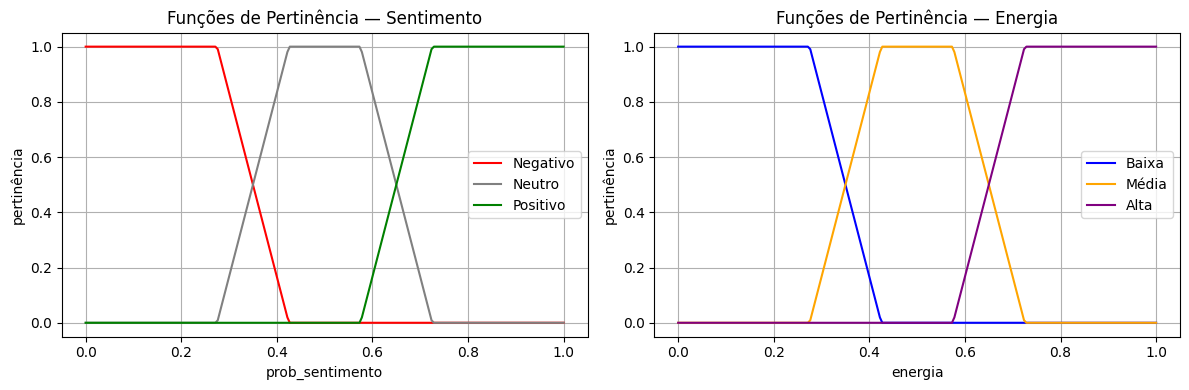

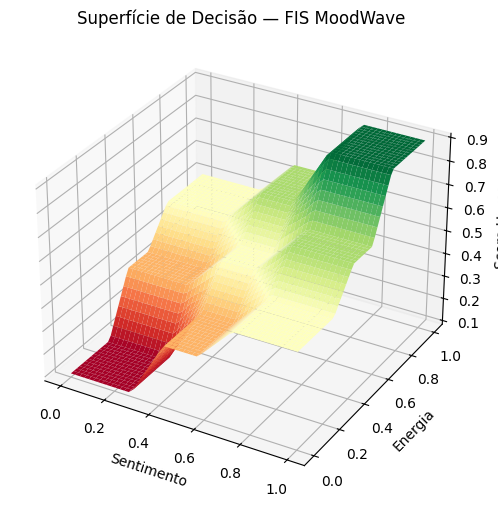

In [1]:
import sys
sys.path.append('../backend')

from fuzzy import SistemaFuzzy
import numpy as np
import matplotlib.pyplot as plt

fis = SistemaFuzzy()

# ============================================================
# Gráfico 1 — Funções de Pertinência
# ============================================================

x = np.linspace(0, 1, 200)

# calcula pertinência de cada ponto para sentimento
sent_neg = [fis._trapezoide(p, None, None, 0.275, 0.425) for p in x]
sent_neu = [fis._trapezoide(p, 0.275, 0.425, 0.575, 0.725) for p in x]
sent_pos = [fis._trapezoide(p, 0.575, 0.725, None, None) for p in x]

# calcula pertinência de cada ponto para energia
ener_bai = [fis._trapezoide(e, None, None, 0.275, 0.425) for e in x]
ener_med = [fis._trapezoide(e, 0.275, 0.425, 0.575, 0.725) for e in x]
ener_alt = [fis._trapezoide(e, 0.575, 0.725, None, None) for e in x]

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# sentimento
axs[0].plot(x, sent_neg, label='Negativo', color='red')
axs[0].plot(x, sent_neu, label='Neutro',   color='gray')
axs[0].plot(x, sent_pos, label='Positivo', color='green')
axs[0].set_title('Funções de Pertinência — Sentimento')
axs[0].set_xlabel('prob_sentimento')
axs[0].set_ylabel('pertinência')
axs[0].legend()
axs[0].grid(True)

# energia
axs[1].plot(x, ener_bai, label='Baixa', color='blue')
axs[1].plot(x, ener_med, label='Média', color='orange')
axs[1].plot(x, ener_alt, label='Alta',  color='purple')
axs[1].set_title('Funções de Pertinência — Energia')
axs[1].set_xlabel('energia')
axs[1].set_ylabel('pertinência')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# Gráfico 2 — Superfície de Decisão
# ============================================================

# gera grade de combinações entre sentimento e energia
sent_vals = np.linspace(0, 1, 50)
ener_vals = np.linspace(0, 1, 50)
S, E = np.meshgrid(sent_vals, ener_vals)

# calcula score_humor para cada combinação
Z = np.zeros_like(S)
for i in range(S.shape[0]):
    for j in range(S.shape[1]):
        Z[i, j] = fis.calcular_humor(S[i, j], E[i, j])

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S, E, Z, cmap='RdYlGn')
ax.set_xlabel('Sentimento')
ax.set_ylabel('Energia')
ax.set_zlabel('Score Humor')
ax.set_title('Superfície de Decisão — FIS MoodWave')
plt.show()